# Gradient Based Explanations

In [1]:
from pathlib import Path

OUT_DIR = Path("out")
OUT_DIR.mkdir(parents=True, exist_ok=True)

def out_path(filename):
    return OUT_DIR / filename


In [2]:
! pip install torch torchvision captum matplotlib pillow

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models, transforms
import matplotlib.pyplot as plt
import requests
from PIL import Image
import numpy as np
import time

# Configuration
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
MODEL_NAME = 'resnet50'
IMAGE_URL = 'https://raw.githubusercontent.com/utkuozbulak/pytorch-cnn-visualizations/master/input_images/cat_dog.png'
TARGET_CLASS = 242  # Boxer dog (ImageNet class index)
N_SAMPLES = 50  # For SmoothGrad and Integrated Gradients

# 1. Load pre-trained model
def load_model(name):
    if hasattr(models, "get_model") and hasattr(models, "get_model_weights"):
        weights = models.get_model_weights(name).DEFAULT
        model = models.get_model(name, weights=weights)
        return model, weights

    if name == "resnet50":
        from torchvision.models import ResNet50_Weights

        weights = ResNet50_Weights.DEFAULT
        model = models.resnet50(weights=weights)
        return model, weights

    model_class = models.__dict__[name]
    model = model_class(pretrained=True)
    return model, None

model, model_weights = load_model(MODEL_NAME)
model = model.to(DEVICE).eval()

# 2. Image preprocessing
if model_weights is not None:
    preprocess = model_weights.transforms()
else:
    preprocess = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])

# 3. Download and preprocess image
print("Downloading image...")
response = requests.get(IMAGE_URL, stream=True)
img = Image.open(response.raw)
input_tensor = preprocess(img).unsqueeze(0).to(DEVICE)
input_tensor.requires_grad = True

# 4. Visualization function
def visualize_explanations(original, explanations, titles, figsize=(15, 15)):
    n_rows = 3
    n_cols = 2
    fig, axs = plt.subplots(n_rows, n_cols, figsize=figsize)
    axs = axs.flatten()
    
    # Original image
    original_np = original.squeeze(0).permute(1, 2, 0).detach().cpu().numpy()
    original_np = original_np * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    original_np = np.clip(original_np, 0, 1)
    
    # Show original in first position
    axs[0].imshow(original_np)
    axs[0].set_title('Original Image')
    axs[0].axis('off')
    
    # Visualize each explanation
    for i, (explanation, title) in enumerate(zip(explanations, titles)):
        expl_np = explanation.detach().cpu().numpy()
        
        # Normalize for visualization
        expl_np = (expl_np - expl_np.min()) / (expl_np.max() - expl_np.min() + 1e-8)
        
        axs[i+1].imshow(expl_np, cmap='viridis')
        axs[i+1].set_title(title)
        axs[i+1].axis('off')
    
    # Hide any unused axes
    for j in range(len(explanations)+1, n_rows*n_cols):
        axs[j].axis('off')
    
    plt.tight_layout()
    plt.show()

# 5. Gradient Explanations (Saliency Map)
def generate_gradients():
    model.zero_grad()
    output = model(input_tensor)
    target_score = output[0, TARGET_CLASS]
    target_score.backward()
    gradients = input_tensor.grad.data[0]
    return gradients.abs().max(dim=0)[0]

# 6. Gradient * Input
def generate_gradient_input():
    model.zero_grad()
    output = model(input_tensor)
    target_score = output[0, TARGET_CLASS]
    target_score.backward()
    gradients = input_tensor.grad.data[0]
    explanation = gradients * input_tensor.data[0]
    return explanation.abs().max(dim=0)[0]

# 7. SmoothGrad
def generate_smoothgrad():
    stdev = 0.15
    total_gradients = torch.zeros_like(input_tensor)
    
    for _ in range(N_SAMPLES):
        # Create noisy input as a new leaf tensor
        noise = torch.normal(0, stdev, size=input_tensor.shape).to(DEVICE)
        noisy_input = (input_tensor.data + noise).detach().requires_grad_(True)
        
        # Forward pass
        output = model(noisy_input)
        target_score = output[0, TARGET_CLASS]
        
        # Backward pass
        model.zero_grad()
        target_score.backward()
        
        # Accumulate gradients
        total_gradients += noisy_input.grad.data
    
    # Average and process
    avg_gradients = total_gradients / N_SAMPLES
    gradients = avg_gradients[0]
    saliency = gradients.abs().max(dim=0)[0]
    return saliency

# 8. Integrated Gradients
def generate_integrated_gradients():
    baseline = torch.zeros_like(input_tensor)
    steps = N_SAMPLES
    total_gradients = torch.zeros_like(input_tensor)
    
    # Create scaled inputs as leaf tensors
    for i in range(0, steps+1):
        alpha = float(i) / steps
        # Create interpolated input as new leaf tensor
        scaled_input = (baseline + alpha * (input_tensor - baseline)).detach().requires_grad_(True)
        
        output = model(scaled_input)
        target_score = output[0, TARGET_CLASS]
        
        model.zero_grad()
        target_score.backward()
        
        total_gradients += scaled_input.grad.data
    
    # Average gradients
    avg_gradients = total_gradients / (steps + 1)
    
    # Calculate integrated gradients
    integrated_grad = (input_tensor - baseline) * avg_gradients
    return integrated_grad[0].abs().sum(dim=0)

# 9. Grad-CAM
def generate_gradcam():
    # Find last convolutional layer
    last_conv_layer = None
    for name, module in model.named_modules():
        if isinstance(module, nn.Conv2d):
            last_conv_layer = module
    
    if last_conv_layer is None:
        raise RuntimeError("No convolutional layer found in model")
    
    # Hook storage
    feature_maps = []
    gradients = []
    
    # Forward hook
    def forward_hook(module, input, output):
        feature_maps.append(output)
    
    # Backward hook
    def backward_hook(module, grad_in, grad_out):
        gradients.append(grad_out[0])
    
    # Register hooks
    hook_forward = last_conv_layer.register_forward_hook(forward_hook)
    hook_backward = last_conv_layer.register_full_backward_hook(backward_hook)
    
    # Forward pass
    output = model(input_tensor)
    target_score = output[0, TARGET_CLASS]
    
    # Backward pass
    model.zero_grad()
    target_score.backward()
    
    # Remove hooks
    hook_forward.remove()
    hook_backward.remove()
    
    # Process features and gradients
    features = feature_maps[0]
    grads = gradients[0]
    
    # Pool gradients spatially
    pooled_grads = torch.mean(grads, dim=[0, 2, 3])
    
    # Weight features by pooled gradients
    weighted_features = features[0] * pooled_grads[:, None, None]
    heatmap = weighted_features.sum(dim=0).relu()
    
    # Normalize and resize
    heatmap /= heatmap.max() + 1e-8
    heatmap = F.interpolate(heatmap[None, None], size=(224, 224), mode='bilinear')[0, 0]
    
    return heatmap

# Main execution
if __name__ == '__main__':
    print(f"Using device: {DEVICE}")
    print(f"Model: {MODEL_NAME}")
    print(f"Target class: {TARGET_CLASS}")
    print(f"Number of samples for SmoothGrad/IG: {N_SAMPLES}")
    
    # Generate explanations with timing
    explanations = []
    titles = []
    
    print("\n1. Generating Gradient (Saliency Map)...")
    start = time.time()
    explanations.append(generate_gradients())
    titles.append("Gradient (Saliency)")
    print(f"   Time: {time.time()-start:.2f}s")
    
    print("\n2. Generating Gradient * Input...")
    start = time.time()
    explanations.append(generate_gradient_input())
    titles.append("Gradient * Input")
    print(f"   Time: {time.time()-start:.2f}s")
    
    print("\n3. Generating SmoothGrad...")
    start = time.time()
    explanations.append(generate_smoothgrad())
    titles.append(f"SmoothGrad (n={N_SAMPLES})")
    print(f"   Time: {time.time()-start:.2f}s")
    
    print("\n4. Generating Integrated Gradients...")
    start = time.time()
    explanations.append(generate_integrated_gradients())
    titles.append(f"Integrated Gradients (n={N_SAMPLES})")
    print(f"   Time: {time.time()-start:.2f}s")
    
    print("\n5. Generating Grad-CAM...")
    start = time.time()
    explanations.append(generate_gradcam())
    titles.append("Grad-CAM")
    print(f"   Time: {time.time()-start:.2f}s")
    
    # Visualize results in 3x2 grid
    print("\nVisualizing results in 3x2 grid...")
    visualize_explanations(
        input_tensor,
        explanations,
        titles,
        figsize=(15, 15)
    )

Using device: cpu
Model: resnet50
Target class: 242
Number of samples for SmoothGrad/IG: 50

1. Generating Gradient (Saliency Map)...
   Time: 29.75s

2. Generating Gradient * Input...
   Time: 31.30s

3. Generating SmoothGrad...


✅ Saved `gradient_saliency.pdf`


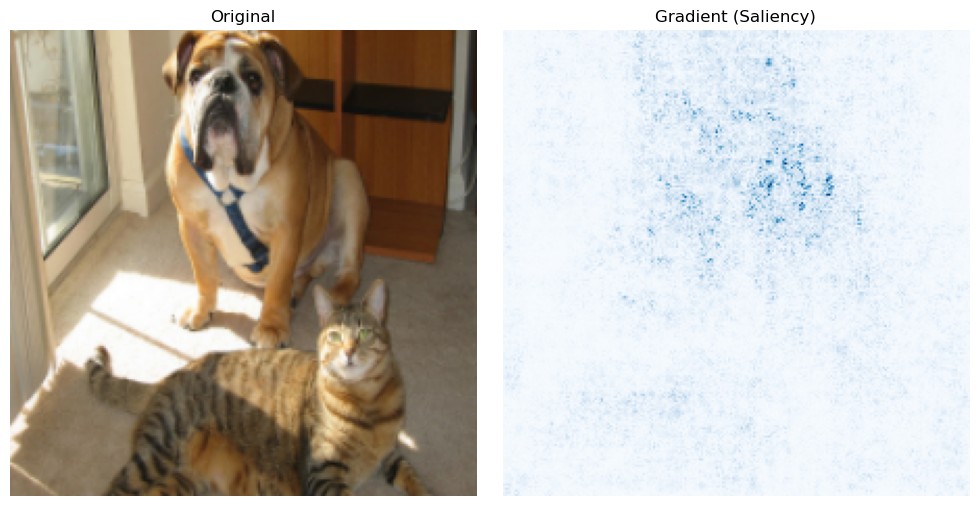

✅ Saved `gradient_*_input.pdf`


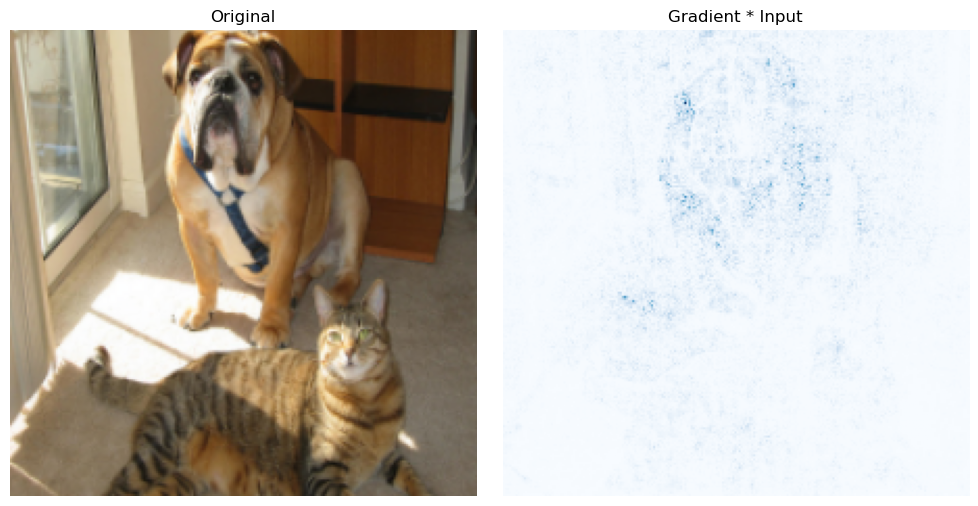

✅ Saved `smoothgrad_n=50.pdf`


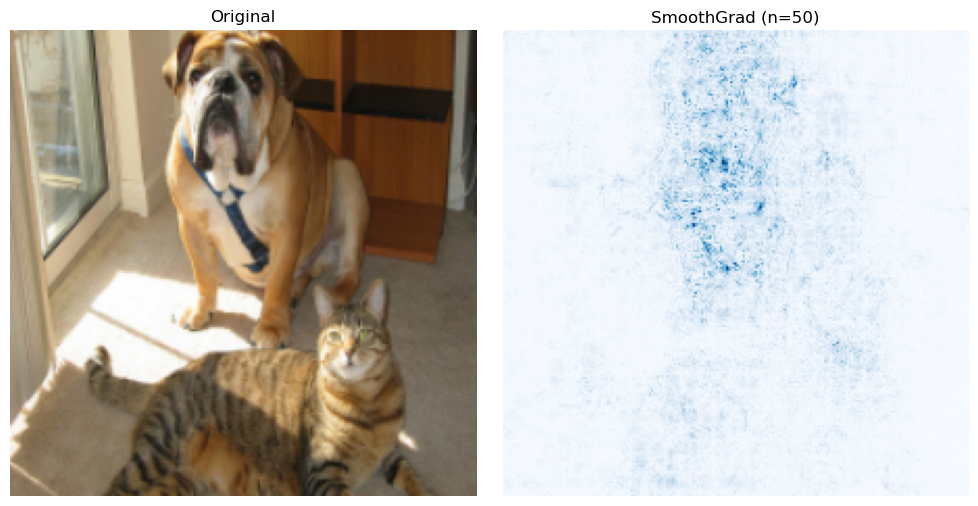

✅ Saved `integrated_gradients_n=50.pdf`


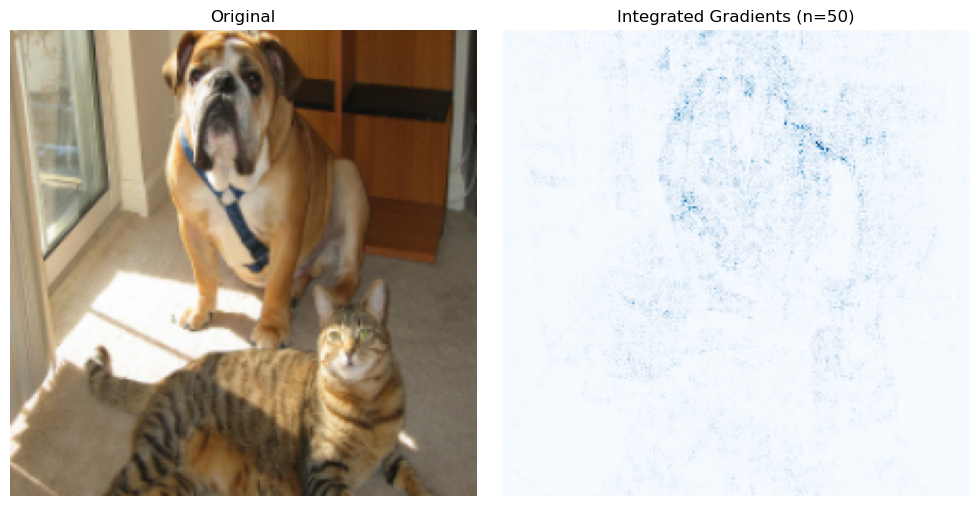

✅ Saved `grad-cam.pdf`


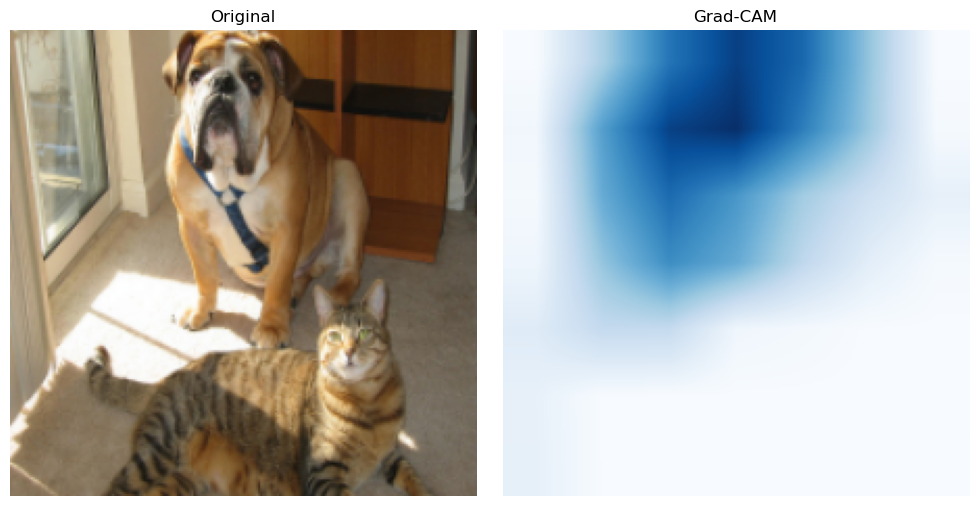

In [ ]:
# After you’ve built `explanations` and `titles` lists:

# Denormalization helper
def denorm(img_tensor):
    img = img_tensor.squeeze(0).permute(1,2,0).cpu().detach().numpy()
    return np.clip(
        img * np.array([0.229,0.224,0.225]) +
        np.array([0.485,0.456,0.406]),
        0,1
    )

for attr, title in zip(explanations, titles):
    # normalize attribution map to [0,1]
    amap = attr.cpu().detach().numpy()
    amap = (amap - amap.min())/(amap.max()-amap.min()+1e-8)

    # plot original + heatmap
    fig, axs = plt.subplots(1, 2, figsize=(10,5))
    
    axs[0].imshow(denorm(input_tensor))
    axs[0].set_title("Original")
    axs[0].axis('off')
    
    # white-to-blue colormap
    axs[1].imshow(amap, cmap='Blues', vmin=0, vmax=1)
    axs[1].set_title(title)
    axs[1].axis('off')
    
    plt.tight_layout()
    
    # save each as PDF (slugify title)
    fname = title.lower().replace(' ', '_').replace('(', '').replace(')', '') + '.pdf'
    fig.savefig(out_path(fname))
    print(f"✅ Saved `{out_path(fname)}`")
    
    plt.show()
